# MegaMart Retail Sales Analysis

**Dataset:** Maven MegaMart — transactions, customer demographics, and product data  
**Tools:** Python, Pandas, Matplotlib  
**Author:** [Amir Abas Ziaee]

---

## Executive Summary

This project analyzes two years of retail transaction data from Maven MegaMart using Pandas. The analysis combines transaction, customer, and product data to examine sales trends, customer spending patterns, and department performance.

The project includes data cleaning, joining multiple datasets, time-series analysis, customer segmentation, and department-level sales analysis to answer a set of business-focused questions.

---

## Business Questions

1. How have total sales changed over time, and is the business growing?
2. Which days of the week generate the most revenue?
3. Which customer age groups and income brackets spend the most?
4. What household compositions show the highest average spend?
5. Which product departments perform best across different age groups?

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

### 1.1 Loading Transactions Data

Loading only the columns needed for this analysis and optimizing data types where possible to reduce memory usage.

In [2]:
cols = ["household_key", "DAY", "PRODUCT_ID", "QUANTITY", "SALES_VALUE"]
dtypes = {"DAY": "Int16", "QUANTITY": "Int32", "PRODUCT_ID": "Int32"}

transactions = pd.read_csv("data/transactions.csv", 
                           dtype=dtypes,
                           usecols=cols
                          )

transactions.shape

(2146311, 5)

In [3]:
transactions.sample(3, random_state=1405)

,household_key,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
653478,1376,264,5564821,1,4.99
1204650,1653,432,8090565,1,2.50
2037721,697,681,1092636,1,2.89


In [4]:
transactions.describe().round(2)

,household_key,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
count,2146311.00,2146311.0,2146311.0,2146311.0,2146311.00
mean,1056.23,389.51,2884714.94,100.97,3.11
std,605.01,190.05,3831949.29,1152.36,4.19
min,1.00,1.0,25671.0,0.0,0.00
25%,548.00,229.0,917231.0,1.0,1.29
50%,1042.00,392.0,1027960.0,1.0,2.00
75%,1581.00,555.0,1132771.0,1.0,3.49
max,2099.00,711.0,18316298.0,89638.0,840.00


In [5]:
transactions.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   household_key  int64  
 1   DAY            Int16  
 2   PRODUCT_ID     Int32  
 3   QUANTITY       Int32  
 4   SALES_VALUE    float64
dtypes: Int16(1), Int32(2), float64(1), int64(1)
memory usage: 59.4 MB


### 1.2 Converting DAY to Actual Dates

The `DAY` column represents the number of days since January 1, 2016. Converting it to a proper date makes time-based analysis more readable.

In [6]:
transactions = (
    transactions
    .assign(
        date=(
            pd.to_datetime("2016", format="%Y")
            + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days")
        )
    )
    .drop(["DAY"], axis=1)
)

transactions.head()

,household_key,PRODUCT_ID,QUANTITY,SALES_VALUE,date
0,1364,842930,1,2.19,2016-01-01
1,1364,897044,1,2.99,2016-01-01
2,1364,920955,1,3.09,2016-01-01
3,1364,937406,1,2.50,2016-01-01
4,1364,981760,1,0.60,2016-01-01


### 1.3 Data Quality Check

In [7]:
print("Missing values:")
print(transactions.isna().sum())
print()
print(f"Date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Unique households: {transactions['household_key'].nunique()}")
print(f"Total transactions: {len(transactions)}")

Missing values:
household_key    0
PRODUCT_ID       0
QUANTITY         0
SALES_VALUE      0
date             0
dtype: int64

Date range: 2016-01-01 to 2017-12-11
Unique households: 2099
Total transactions: 2146311


No missing values were found. The dataset covers nearly two years of transaction history, from January 2016 through December 2017.

**Note:** Because the final month is incomplete, December 2017 will be treated carefully in time-based analyses.

---
## 2. Time-Based Analysis

### 2.1 Monthly Sales Trend

Monthly sales across the entire dataset. December 2017 is excluded because the month is incomplete.

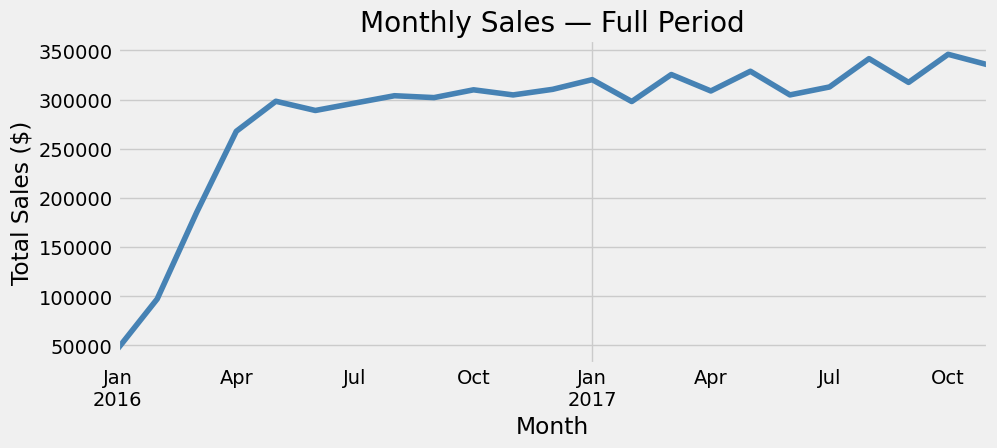

In [8]:
(
    transactions
    .set_index("date")
    .loc[:, "SALES_VALUE"]
    .resample("MS")
    .sum()
    .loc[: "2017-11-01"]
    .plot(
        title="Monthly Sales — Full Period",
        xlabel="Month",
        ylabel="Total Sales ($)",
        figsize=(10, 4),
        color="steelblue",
        legend=False
    )
);

**Insight:** Monthly sales generally increased over time.

### 2.2 Year-over-Year Comparison (2016 vs 2017)

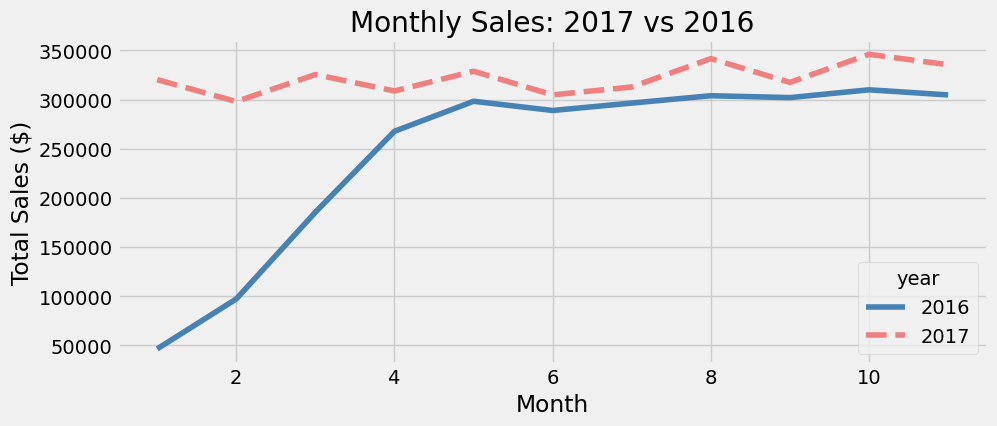

In [9]:
transactions["year"] = transactions["date"].dt.year
transactions["month"] = transactions["date"].dt.month

(
    transactions.pivot_table(
    index="month",
    columns="year",
    values="SALES_VALUE",
    aggfunc="sum")
    .drop(12, axis=0)
    .plot(
        title="Monthly Sales: 2017 vs 2016",
        xlabel="Month",
        ylabel="Total Sales ($)",
        figsize=(10, 4),
        color=["steelblue", "lightcoral"],
        style=["-", "--"]
    )
);

**Insight:** 2017 monthly sales closely follow 2016 levels with a slight upward shift in the first quarter of the year.

**Note:** December 2017 is excluded from comparison due to incomplete data.

### 2.3 Sales by Day of Week

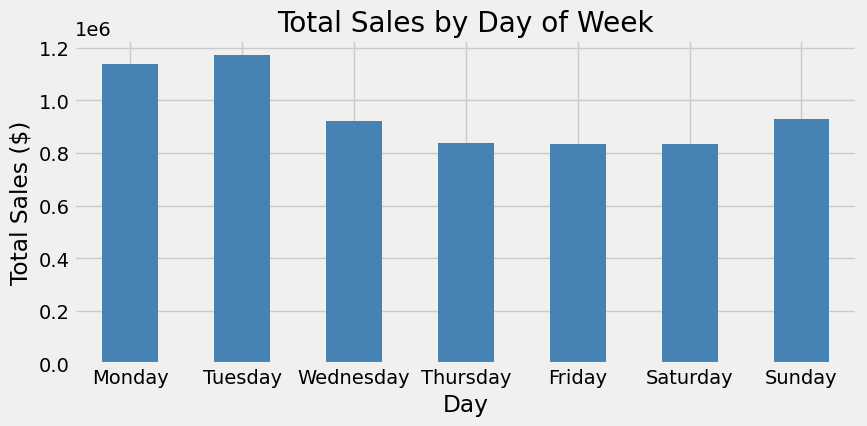

In [10]:
day_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

ax = (
    transactions
    .groupby(transactions["date"].dt.dayofweek)
    .agg({"SALES_VALUE": "sum"})
    .plot.bar(
        title="Total Sales by Day of Week",
        xlabel="Day",
        ylabel="Total Sales ($)",
        figsize=(9, 4),
        color="steelblue",
        rot=0,
        legend=False
    )
)

ax.set_xticklabels(day_labels);

**Insight:** Sales are distributed evenly across the week, with a mild peak on Sunday. 

---
## 3. Customer Demographics Analysis

### 3.1 Loading Demographics Data

The demographics table contains household-level attributes such as age group, income bracket, and household composition. These fields will be joined with transaction data to analyze customer spending patterns.

In [11]:
dem_cols = ["AGE_DESC", "INCOME_DESC", "household_key", "HH_COMP_DESC"]
dem_dtypes = {"AGE_DESC": "category", "INCOME_DESC": "category", "HH_COMP_DESC": "category"}

demographics = pd.read_csv("data/demographics.csv",
                           usecols=dem_cols,
                           dtype=dem_dtypes
                          )

demographics.head()

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16


In [12]:
demographics.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AGE_DESC       801 non-null    category
 1   INCOME_DESC    801 non-null    category
 2   HH_COMP_DESC   801 non-null    category
 3   household_key  801 non-null    int64   
dtypes: category(3), int64(1)
memory usage: 10.7 KB


In [13]:
print(f"Transaction households: {transactions['household_key'].nunique()}")
print(f"Demographic households: {demographics['household_key'].nunique()}")

Transaction households: 2099
Demographic households: 801


**Note:** Demographic information is available for 801 of the 2,099 households in the transaction data. All demographic analyses in the following sections are based on this matched subset of customers.

### 3.2 Aggregate Total Sales per Household

Aggregate transaction-level sales to the household level before combining them with demographic information.

In [14]:
household_sales = (
    transactions
    .groupby("household_key")
    .agg({"SALES_VALUE": "sum"})
)

household_sales.head()

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06


### 3.3 Join Sales with Demographics

Using an inner join to keep only households that appear in both tables — this ensures we only analyze customers we have demographic information for.

In [15]:
household_sales_demo = (
    household_sales
    .merge(
        demographics,
        how="inner",
        on="household_key",
        validate="1:1"
    )
)

print(f"Rows after join: {len(household_sales_demo):,}")
household_sales_demo.head()

Rows after join: 668


,household_key,SALES_VALUE,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1,4330.16,65+,35-49K,2 Adults No Kids
1,7,3400.05,45-54,50-74K,2 Adults No Kids
2,8,5534.97,25-34,25-34K,2 Adults Kids
3,13,13190.92,25-34,75-99K,2 Adults Kids
4,16,1512.02,45-54,50-74K,Single Female


**Note:** The final dataset contains 668 households with both demographic information and recorded transactions.

### 3.4 Sales by Age Group

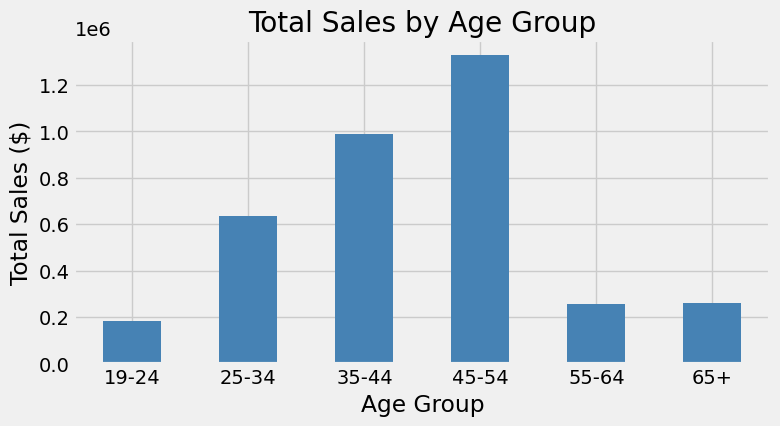

In [16]:
(
    household_sales_demo
    .groupby("AGE_DESC", observed=True)
    .agg({"SALES_VALUE": "sum"})
    .sort_index()
    .plot.bar(
        title="Total Sales by Age Group",
        xlabel="Age Group",
        ylabel="Total Sales ($)",
        figsize=(8, 4),
        color="steelblue",
        rot=0,
        legend=False
    )
);

**Insight:** Households in the 45-54 age group generate the most total sales, followed by those aged 35-44. The 19-24 segment contributes the least.

### 3.5 Sales by Income Bracket

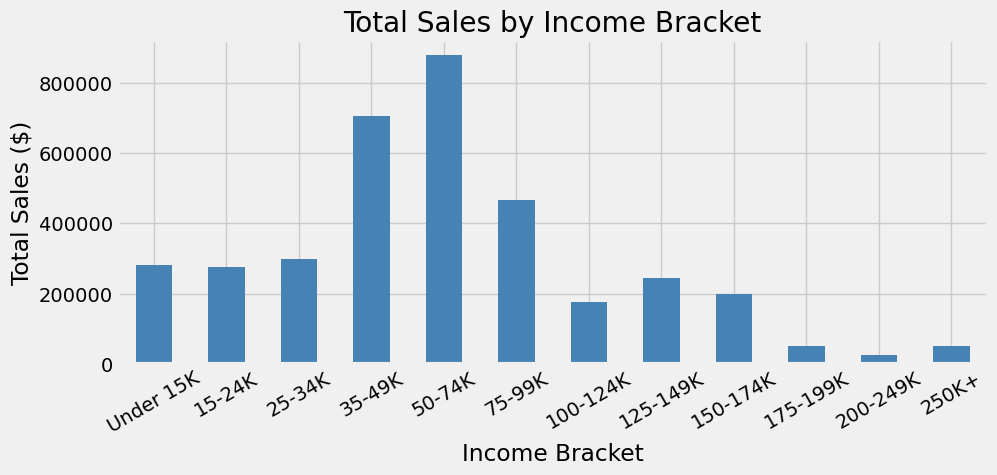

In [17]:
income_order = ["Under 15K", "15-24K", "25-34K", "35-49K", "50-74K",
                "75-99K", "100-124K", "125-149K", "150-174K", "175-199K",
                "200-249K", "250K+"]

household_sales_demo["INCOME_DESC"] = pd.Categorical(
    household_sales_demo["INCOME_DESC"],
    categories=income_order,
    ordered=True)
(
    household_sales_demo
    .groupby("INCOME_DESC", observed=True)
    .agg({"SALES_VALUE": "sum"})
    .sort_index()
    .plot.bar(
        title="Total Sales by Income Bracket",
        xlabel="Income Bracket",
        ylabel="Total Sales ($)",
        figsize=(10, 4),
        color="steelblue",
        rot=30,
        legend=False
    )
);

**Insight:** Sales are highest among households earning between 35k and 74k and generally decline at the highest income levels.

### 3.6 Average Household Spend by Age & Household Composition

Compare average household spending across age groups and household compositions.

In [18]:
(
    household_sales_demo
    .pivot_table(
        index="AGE_DESC",
        columns="HH_COMP_DESC",
        values="SALES_VALUE",
        aggfunc="mean",
        margins=True,
        observed=True
    )
    .round(0)
    .style.background_gradient(cmap="RdYlGn", axis=None)
)

HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7269.000000,5429.000000,4021.000000,4576.000000,3217.000000,4911.000000,4692.000000
25-34,5512.000000,5754.000000,5639.000000,4807.000000,4910.000000,7356.000000,5436.000000
35-44,6298.000000,6692.000000,6260.000000,6015.000000,4844.000000,4228.000000,6091.000000
45-54,6633.000000,6610.000000,5840.000000,4549.000000,4637.000000,4844.000000,5535.000000
55-64,3065.000000,4696.000000,5752.000000,4816.000000,3923.000000,7974.000000,5169.000000
65+,4041.000000,5537.000000,4614.000000,4060.000000,3872.000000,2879.000000,4341.000000
All,6033.000000,6280.000000,5600.000000,4896.000000,4545.000000,4936.000000,5468.000000


**Insight:** Average household spending peaks among households aged 35–44 and remains relatively high for those aged 45–54. Households with children generally spend more than single-person households, while spending tends to decline among the oldest age groups.

In [19]:
# free up memory before loading the next dataset
del household_sales, household_sales_demo

---
## 4. Product Department Analysis

### 4.1 Loading Product Data

Load product department information to analyze sales performance across merchandise categories.

In [20]:
product_cols = ["PRODUCT_ID", "DEPARTMENT"]
product_dtypes = {"PRODUCT_ID": "Int32", "DEPARTMENT": "category"}

product = pd.read_csv("data/products.csv",
                      usecols=product_cols,
                      dtype=product_dtypes
                     )

product.head()

,PRODUCT_ID,DEPARTMENT
0,25671,GROCERY
1,26081,MISC. TRANS.
2,26093,PASTRY
3,26190,GROCERY
4,26355,GROCERY


### 4.2 Building the Full Joined Dataset

Combining transactions, demographics, and product data into a single dataset for department-level analysis.

In [21]:
trans_demo_dept = (
    transactions
    .merge(demographics, how="inner", on="household_key", validate="m:1")
    .merge(product, how="inner", on="PRODUCT_ID", validate="m:1")
)

print(f"Rows in joined dataset: {len(trans_demo_dept):,}")
trans_demo_dept.info(memory_usage="deep")

Rows in joined dataset: 1,161,575
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161575 entries, 0 to 1161574
Data columns (total 11 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   household_key  1161575 non-null  int64         
 1   PRODUCT_ID     1161575 non-null  Int32         
 2   QUANTITY       1161575 non-null  Int32         
 3   SALES_VALUE    1161575 non-null  float64       
 4   date           1161575 non-null  datetime64[ns]
 5   year           1161575 non-null  int32         
 6   month          1161575 non-null  int32         
 7   AGE_DESC       1161575 non-null  category      
 8   INCOME_DESC    1161575 non-null  category      
 9   HH_COMP_DESC   1161575 non-null  category      
 10  DEPARTMENT     1161575 non-null  category      
dtypes: Int32(2), category(4), datetime64[ns](1), float64(1), int32(2), int64(1)
memory usage: 51.0 MB


**Note:** The joined dataset contains only transactions from households with available demographic information, reducing the number of records from 2.1 million to 1.16 million.

### Data Quality Check: Department Field

The DEPARTMENT column contains whitespace-only values that appear as a separate category. These records are removed before performing department-level analysis.

In [22]:
# removing leading/trailing whitespaces
trans_demo_dept["DEPARTMENT"] = (
    trans_demo_dept["DEPARTMENT"]
    .astype(str)
    .str.strip()
)

# dropping empty department values
trans_demo_dept = trans_demo_dept.loc[
    trans_demo_dept["DEPARTMENT"].ne("")
]

# converting back to categorical
trans_demo_dept["DEPARTMENT"] = trans_demo_dept["DEPARTMENT"].astype("category")

# verifying results
print(f"Remaining rows: {len(trans_demo_dept):,}")
print(f"Unique departments after cleaning: {trans_demo_dept['DEPARTMENT'].nunique()}")

Remaining rows: 1,157,529
Unique departments after cleaning: 37


### 4.3 Sales by Department and Age Group

Compare total sales across product departments and age groups. The heatmap highlights the highest-spending age group within each department.

In [23]:
dept_age_pivot = trans_demo_dept.pivot_table(
    index="DEPARTMENT",
    columns="AGE_DESC",
    values="SALES_VALUE",
    aggfunc="sum",
    observed=True
)
dept_age_pivot.style.background_gradient(cmap="RdYlGn", axis=1)

AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
AUTOMOTIVE,11.640000,21.250000,72.580000,55.920000,nan,16.370000
CHEF SHOPPE,81.300000,134.160000,348.530000,418.240000,80.860000,149.240000
CNTRL/STORE SUP,2.000000,0.000000,1.000000,9.950000,2.000000,0.100000
COSMETICS,698.630000,2273.030000,4362.020000,5187.570000,986.260000,600.900000
COUP/STR & MFG,7.490000,48.420000,121.200000,154.550000,40.680000,20.490000
DAIRY DELI,3.800000,3.850000,7.390000,16.750000,3.140000,1.940000
DELI,4043.300000,18181.940000,34577.290000,44334.220000,9850.540000,10462.330000
DELI/SNACK BAR,nan,nan,6.980000,1.560000,nan,3.310000
DRUG GM,25297.430000,85298.050000,126480.340000,177007.130000,29220.930000,32759.760000


**Insight:** Households aged 35–44 and 45–54 generate the highest sales across most departments. This pattern is especially visible in major categories such as Grocery, Produce, Meat, and Drug GM, while younger households contribute comparatively less across most departments.

---
## 5. Key Findings

This analysis looked at two years of sales data across about 2,100 households and multiple product departments. Here are the main takeaways.

**1. Sales are stable with a small increase**
Monthly sales don’t change much over time, but 2017 is slightly higher than 2016.

**2. Weekdays and weekends look similar**
Sales are distributed evenly across the week. Sunday is a bit higher, but not by a large margin.

**3. Families aged 35–54 have the highest average spend**
Households with children in the 35–44 and 45–54 age groups record the highest average spend per household.

**4. Grocery is the main driver of sales**
Most spending comes from grocery and everyday essentials across all customer groups.